Pewnie. Poniżej masz część teoretyczną w **Markdown**, a potem osobno **kod w Pythonie**.

---

# Układ Hénona — opis teoretyczny

## Definicja odwzorowania

Odwzorowanie Hénona zależy od parametrów $a,b$ i ma postać

$$
h_{a,b}(x,y) = (a - by - x^2,; x).
$$

To znaczy, że jeśli w chwili $n$ punkt ma współrzędne $(x_n,y_n)$, to w następnym kroku otrzymujemy

$$
x_{n+1} = a - b y_n - x_n^2,
$$

$$
y_{n+1} = x_n.
$$

## Interpretacja

Układ jest dyskretnym układem dynamicznym w $\mathbb{R}^2$.

W każdym kroku:

* nowa współrzędna $y$ jest po prostu poprzednią wartością $x$,
* nowa współrzędna $x$ zależy nieliniowo od poprzedniego $x$ oraz liniowo od poprzedniego $y$.

Zatem stan układu w chwili $n+1$ zależy od stanu w chwili $n$, a kolejne iteracje tworzą orbitę punktu początkowego.

## Co oznacza „długoterminowe zachowanie”?

Dla zadanego punktu początkowego $(x_0,y_0)$ rozważamy ciąg iteracji

$$
(x_0,y_0),; (x_1,y_1),; (x_2,y_2),; \dots
$$

otrzymany przez wielokrotne stosowanie odwzorowania Hénona.

Długoterminowe zachowanie oznacza obserwację tego, co dzieje się z orbitą po dużej liczbie kroków:

* czy punkt zbiega do punktu stałego,
* czy wpada w cykl okresowy,
* czy ucieka do nieskończoności,
* czy tworzy bardziej złożony, chaotyczny zbiór.

## Co ma robić program?

Program powinien:

1. przyjmować parametry $a$ i $b$,
2. przyjmować warunek początkowy $(x_0,y_0)$,
3. przyjmować liczbę iteracji $k$,
4. obliczać kolejne punkty orbity,
5. narysować je na płaszczyźnie.

Najczęściej dla lepszej wizualizacji pomija się kilka pierwszych iteracji, ponieważ początkowy fragment orbity może nie oddawać jeszcze właściwego zachowania asymptotycznego.

## Typowy algorytm

Dla danych $a,b,(x_0,y_0),k$ wykonujemy:

1. ustaw $(x,y)=(x_0,y_0)$,
2. dla kolejnych kroków oblicz:
   $$
   x_{\text{new}} = a - b y - x^2,
   $$
   $$
   y_{\text{new}} = x,
   $$
3. zastąp $(x,y)$ przez $(x_{\text{new}},y_{\text{new}})$,
4. zapisz punkt,
5. po wykonaniu $k$ kroków narysuj wszystkie otrzymane punkty.

## Uwaga praktyczna

Dla klasycznych parametrów, np.

$$
a = 1.4,\qquad b = 0.3,
$$

odwzorowanie Hénona daje słynny atraktor Hénona, czyli zbiór o bardzo złożonej strukturze, związany z dynamiką chaotyczną.


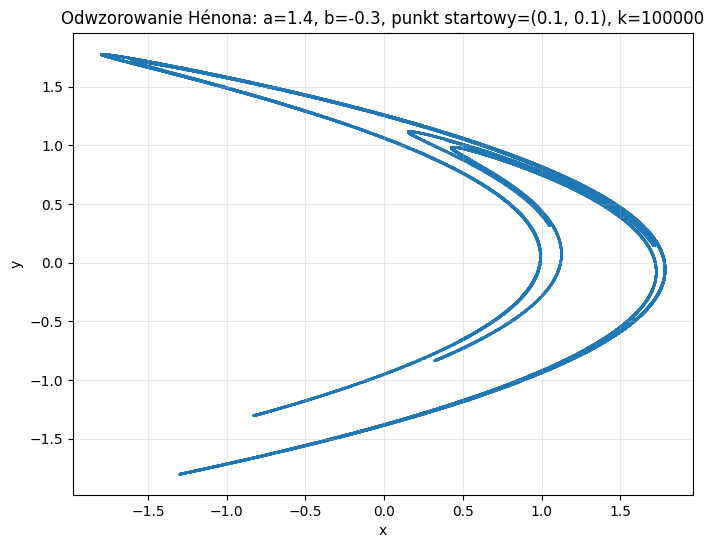

In [ ]:
from zadanie12 import plot_henon

a = 1.4
b = -0.3
x0 = 0.1
y0 = 0.1
k = 100000

plot_henon(a=a, b=b, x0=x0, y0=y0, k=k, burn_in=100, point_size=0.2)

Testing a=1.200, b=-0.400 ...


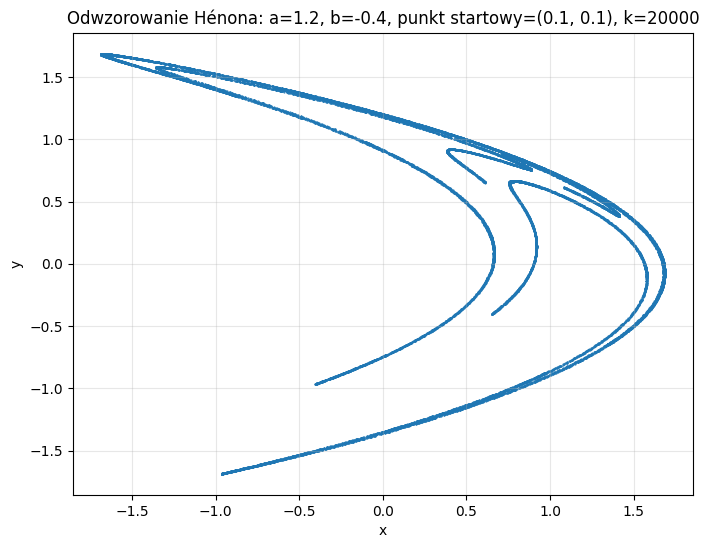

 saved -> henon_a1_200_b-0_400_png
Testing a=1.200, b=-0.300 ...


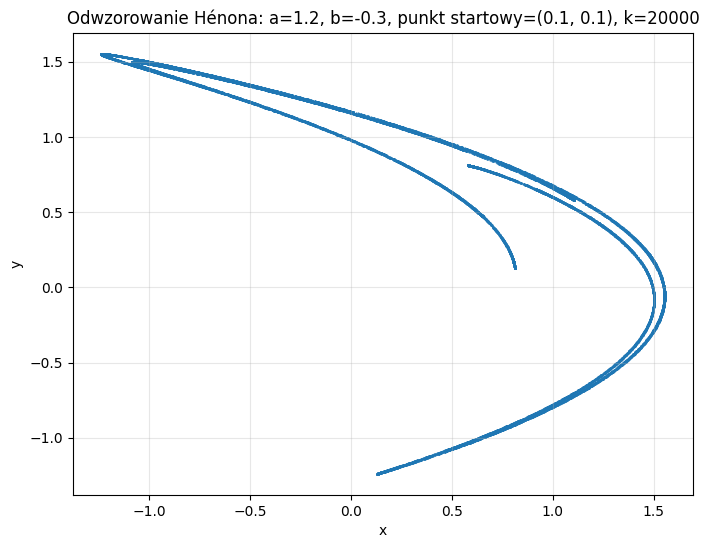

 saved -> henon_a1_200_b-0_300_png
Testing a=1.200, b=-0.200 ...


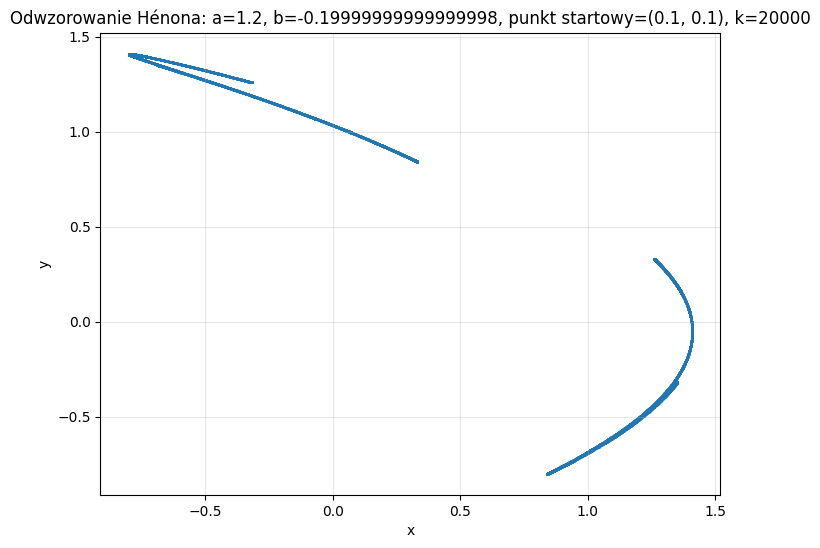

 saved -> henon_a1_200_b-0_200_png
Testing a=1.200, b=-0.100 ...


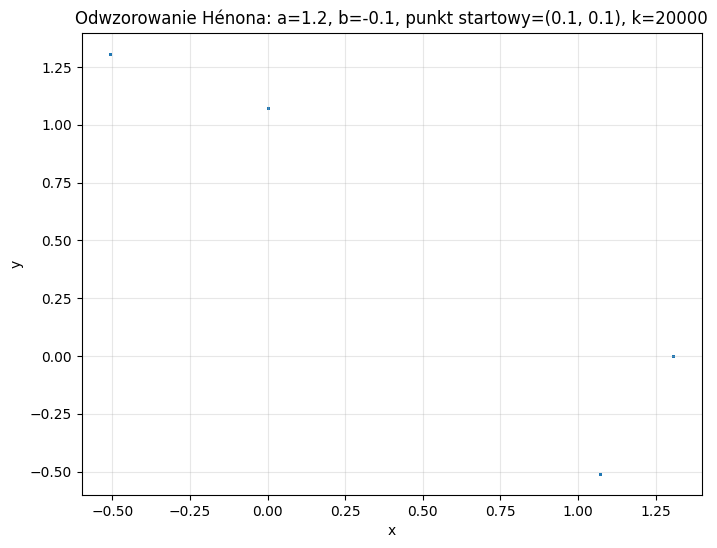

 saved -> henon_a1_200_b-0_100_png
Testing a=1.300, b=-0.400 ...


c:\Users\pawel.drzyzga\Documents\studia\UKLADYDYNAMICZNE20252026\20260323\funct.py:11: RuntimeWarning: overflow encountered in scalar power
  x_new = a - b * y - x**2


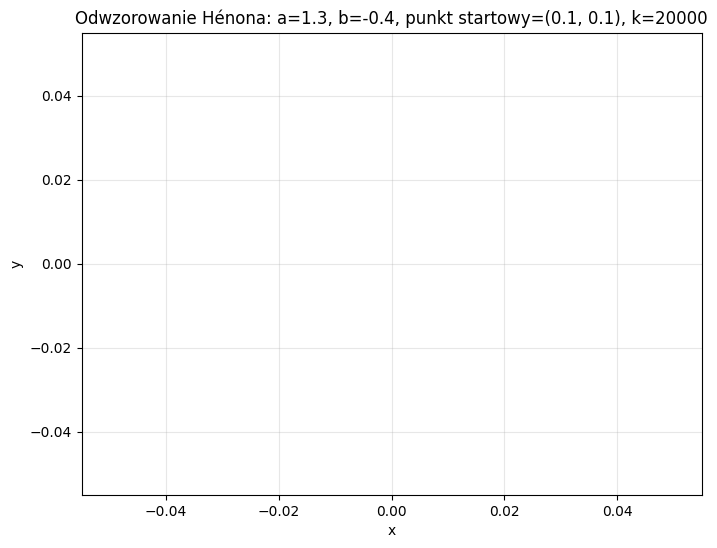

 saved -> henon_a1_300_b-0_400_png
Testing a=1.300, b=-0.300 ...


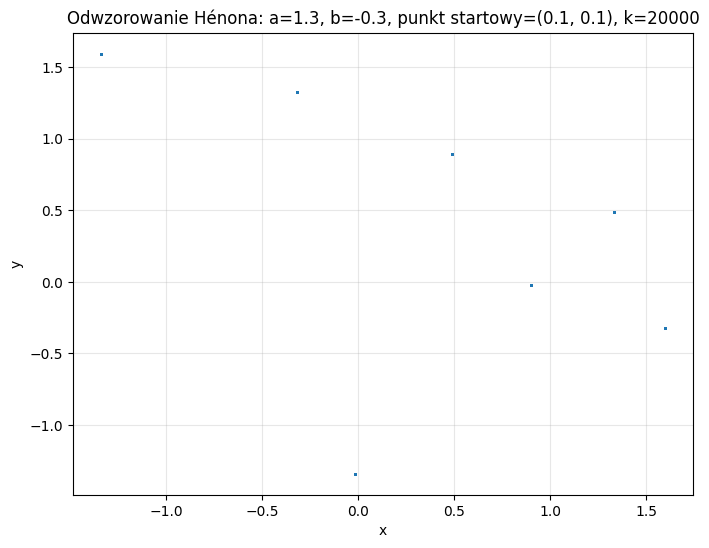

 saved -> henon_a1_300_b-0_300_png
Testing a=1.300, b=-0.200 ...


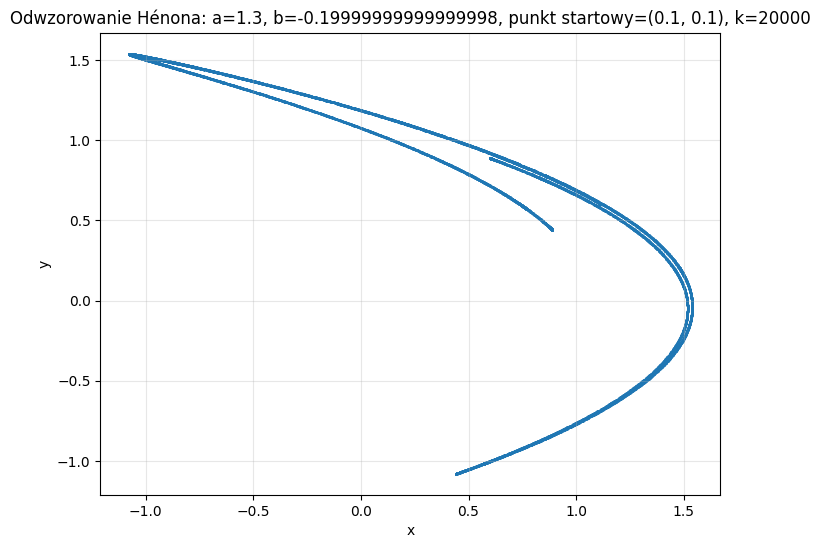

 saved -> henon_a1_300_b-0_200_png
Testing a=1.300, b=-0.100 ...


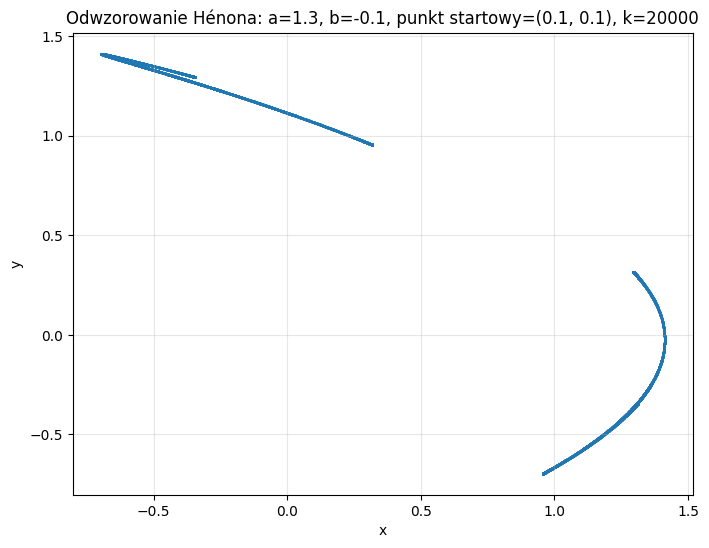

 saved -> henon_a1_300_b-0_100_png
Testing a=1.400, b=-0.400 ...


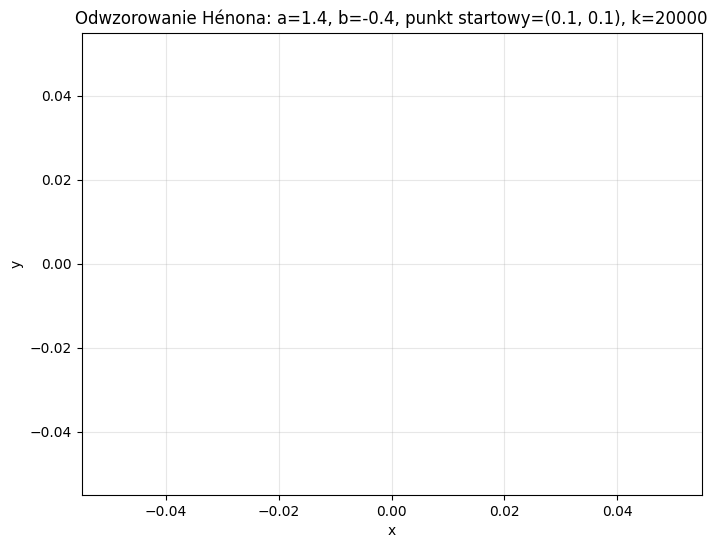

 saved -> henon_a1_400_b-0_400_png
Testing a=1.400, b=-0.300 ...


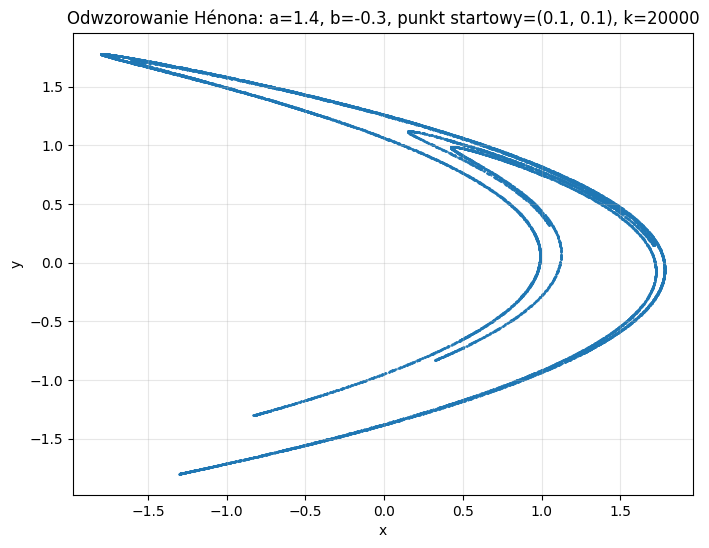

 saved -> henon_a1_400_b-0_300_png
Testing a=1.400, b=-0.200 ...


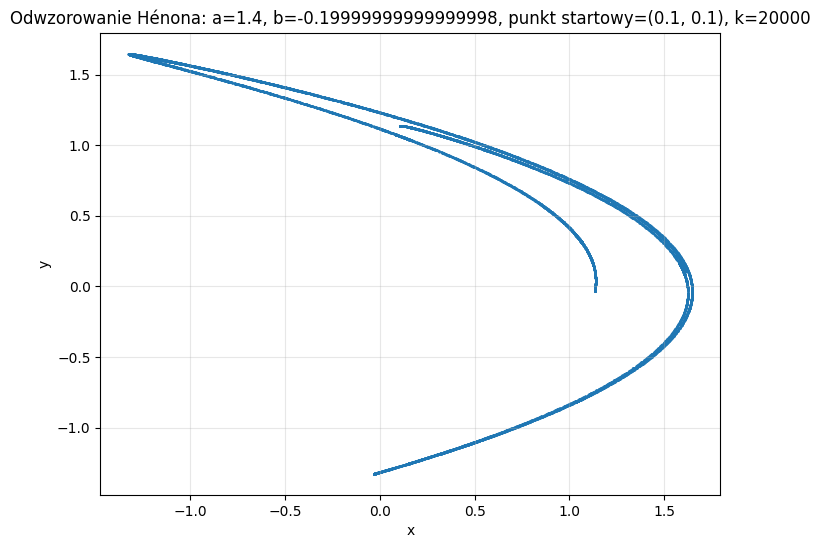

 saved -> henon_a1_400_b-0_200_png
Testing a=1.400, b=-0.100 ...


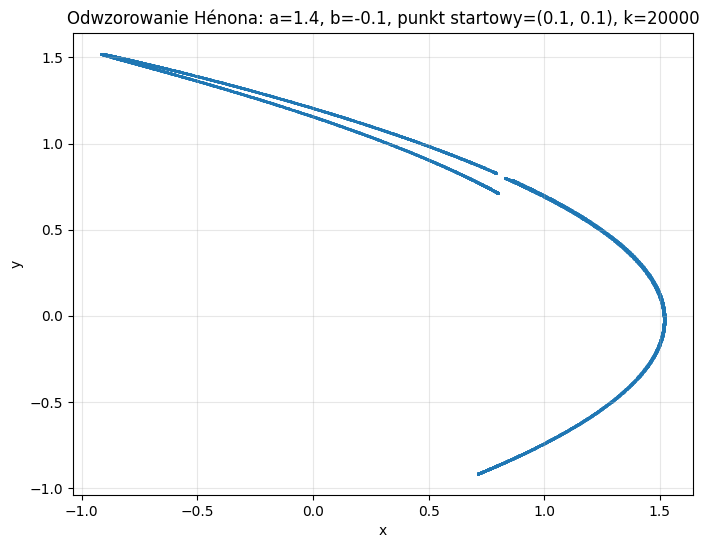

 saved -> henon_a1_400_b-0_100_png
Testing a=1.500, b=-0.400 ...


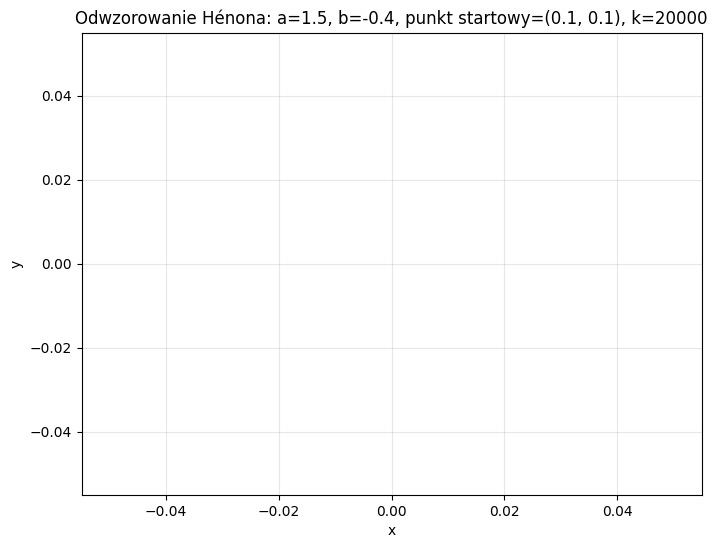

 saved -> henon_a1_500_b-0_400_png
Testing a=1.500, b=-0.300 ...


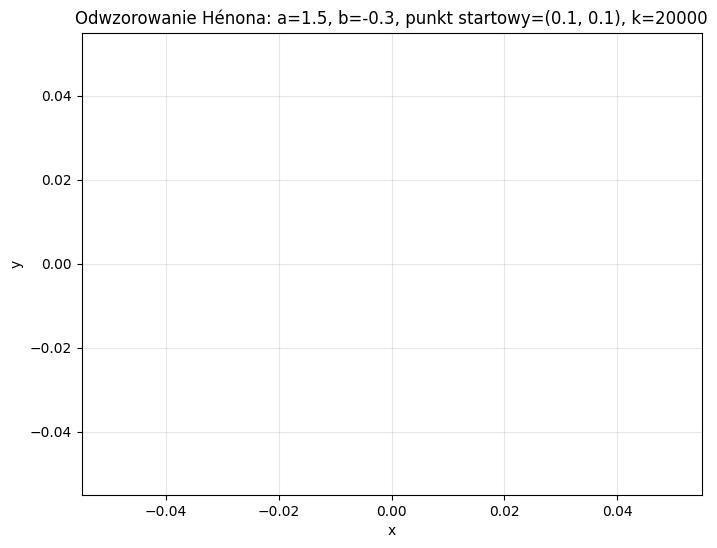

 saved -> henon_a1_500_b-0_300_png
Testing a=1.500, b=-0.200 ...


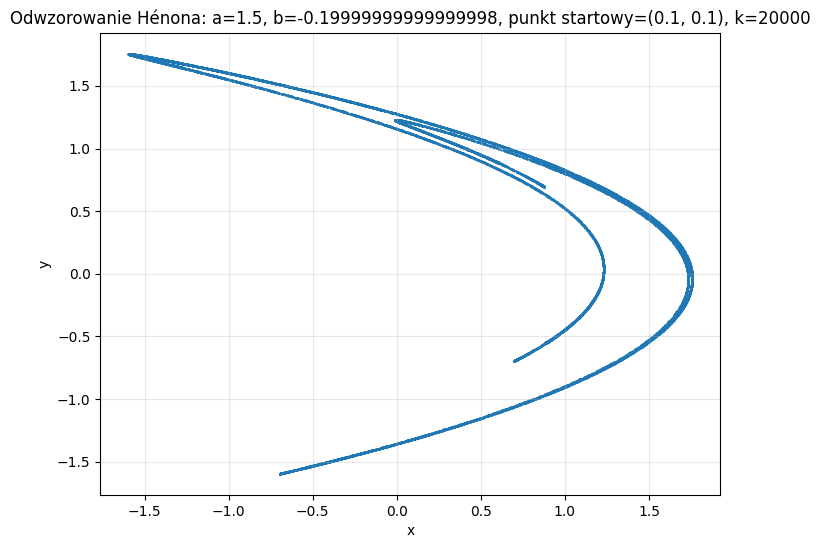

 saved -> henon_a1_500_b-0_200_png
Testing a=1.500, b=-0.100 ...


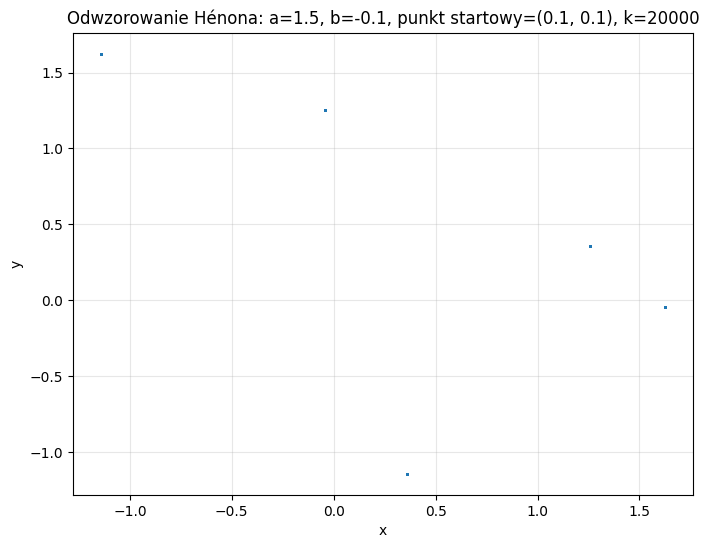

 saved -> henon_a1_500_b-0_100_png


In [8]:
import numpy as np

import matplotlib.pyplot as plt

# siatka parametrów (dostosuj zakres/rozdzielczość)
a_vals = np.linspace(1.2, 1.5, 4)
b_vals = np.linspace(-0.4, -0.1, 4)

# użyj mniejszej liczby iteracji dla szybszych testów (nie nadpisuje k)
k_test = 20000

for ai in a_vals:
    for bi in b_vals:
        print(f"Testing a={ai:.3f}, b={bi:.3f} ...")
        plot_henon(a=ai, b=bi, x0=x0, y0=y0, k=k_test, burn_in=200, point_size=0.3)
        plt.gca().set_title(f"a={ai:.3f}, b={bi:.3f}")
        fname = f"henon_a{ai:.3f}_b{bi:.3f}.png".replace('.', '_')
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.close()
        print(" saved ->", fname)

# Zadanie 3

Rozważamy odwzorowanie Hénona

$$
h_{a,b}(x,y) = (a - by - x^2,; x).
$$

Chcemy wyznaczyć jego punkty stałe, czyli punkty $(x,y)$ spełniające

$$
h_{a,b}(x,y) = (x,y).
$$

To daje układ

$$
\begin{cases}
a - by - x^2 = x, \
x = y.
\end{cases}
$$

Z drugiego równania mamy od razu

$$
y=x.
$$

Podstawiając do pierwszego:

$$
a - bx - x^2 = x.
$$

Po przeniesieniu wszystkiego na jedną stronę:

$$
x^2 + (1+b)x - a = 0.
$$

Zatem współrzędna $x$ punktu stałego musi być pierwiastkiem trójmianu kwadratowego

$$
Q_1(x)=x^2+(1+b)x-a.
$$

## Warunek istnienia punktów stałych

Równanie kwadratowe ma rozwiązania rzeczywiste wtedy i tylko wtedy, gdy jego wyróżnik jest nieujemny:

$$
\Delta = (1+b)^2 + 4a \ge 0.
$$

Czyli:

$$
a \ge -\frac14(1+b)^2.
$$

Rozpatrzmy trzy przypadki.

### 1. Gdy

$$
a < -\frac14(1+b)^2,
$$

wtedy

$$
\Delta < 0,
$$

więc równanie nie ma rozwiązań rzeczywistych. Zatem odwzorowanie $h_{a,b}$ **nie ma punktów stałych**.

### 2. Gdy

$$
a = -\frac14(1+b)^2,
$$

wtedy

$$
\Delta = 0,
$$

więc istnieje dokładnie jeden pierwiastek podwójny:

$$
x = -\frac{1+b}{2}.
$$

Ponieważ $y=x$, jedyny punkt stały ma postać

$$
\left(-\frac{1+b}{2},; -\frac{1+b}{2}\right).
$$

### 3. Gdy

$$
a > -\frac14(1+b)^2,
$$

wtedy

$$
\Delta > 0,
$$

więc istnieją dwa różne pierwiastki:

$$
x_{1,2}=\frac{-(1+b)\pm\sqrt{(1+b)^2+4a}}{2}.
$$

Ponieważ $y=x$, dostajemy dwa punkty stałe:

$$
p_\pm
=====

\left(
\frac{-(1+b)\pm\sqrt{(1+b)^2+4a}}{2},
\frac{-(1+b)\pm\sqrt{(1+b)^2+4a}}{2}
\right).
$$

## Wniosek

Odwzorowanie $h_{a,b}$:

* **nie ma punktów stałych**, gdy
  $$
  a < -\frac14(1+b)^2,
  $$
* **ma dokładnie jeden punkt stały**, gdy
  $$
  a = -\frac14(1+b)^2,
  $$
* **ma dokładnie dwa punkty stałe**, gdy
  $$
  a > -\frac14(1+b)^2.
  $$

Współrzędne punktów stałych, gdy istnieją, są dane wzorem

$$
\left(
\frac{-(1+b)\pm\sqrt{(1+b)^2+4a}}{2},
\frac{-(1+b)\pm\sqrt{(1+b)^2+4a}}{2}
\right).
$$

---




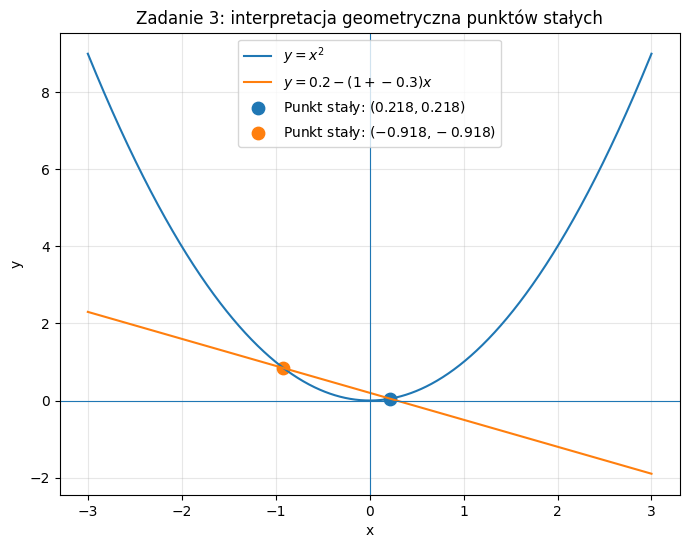

In [12]:
from zadanie4 import plot_fixed_points_geometry

a = 0.2
b = -0.3
plot_fixed_points_geometry(a=a, b=b, x_min=-3, x_max=3)

# Zadanie 4

Chcemy pokazać, że odwzorowanie $h_{a,b}$ ma **ściśle orbitę okresu 2** wtedy i tylko wtedy, gdy

$$
a > \frac34(1+b)^2,
$$

oraz wyznaczyć tę orbitę.

Przypomnijmy, że orbita okresu $2$ to para różnych punktów
$$
(x,y),\quad (u,v),
$$
taka że

$$
h_{a,b}(x,y)=(u,v), \qquad h_{a,b}(u,v)=(x,y),
$$

i dodatkowo punkty muszą być różne.

## Krok 1. Jak musi wyglądać orbita okresu 2?

Ponieważ

$$
h_{a,b}(x,y)=(a-by-x^2,;x),
$$

to druga współrzędna obrazu punktu $(x,y)$ jest równa $x$.

Jeżeli więc punkt $(x,y)$ należy do orbity okresu $2$, to po jednym kroku przechodzi w pewien punkt, którego druga współrzędna jest równa $x$. Po dwóch krokach ma wrócić do $(x,y)$, więc naturalnie para punktów w takiej orbicie musi mieć postać

$$
(x,y)\longmapsto (y,x)\longmapsto (x,y).
$$

Zatem punkt $(x,y)$ należy do orbity okresu $2$ wtedy i tylko wtedy, gdy

$$
h_{a,b}(x,y)=(y,x).
$$

To daje układ

$$
\begin{cases}
a-by-x^2 = y, \
x = x.
\end{cases}
$$

Druga równość jest automatyczna, więc istotne równanie to

$$
y = a - by - x^2.
\tag{1}
$$

Jednocześnie, ponieważ także $(y,x)$ ma wracać do $(x,y)$, musi być spełnione

$$
x = a - bx - y^2.
\tag{2}
$$

Zatem punkty orbity okresu $2$ muszą spełniać układ

$$
\begin{cases}
y = a - by - x^2, \
x = a - bx - y^2.
\end{cases}
$$

## Krok 2. Odejmujemy równania

Odejmijmy stronami równanie (2) od równania (1):

$$
y-x = \bigl(a-by-x^2\bigr)-\bigl(a-bx-y^2\bigr).
$$

Po uproszczeniu:

$$
y-x = -b(y-x) + (y^2-x^2).
$$

Korzystamy z rozkładu

$$
y^2-x^2=(y-x)(x+y),
$$

więc

$$
y-x = -b(y-x) + (y-x)(x+y).
$$

Wyłączamy wspólny czynnik $(y-x)$:

$$
(y-x)\bigl(1+b-(x+y)\bigr)=0.
$$

Stąd mamy dwie możliwości:

### Przypadek A: $y=x$

Wtedy punkt spełnia

$$
h_{a,b}(x,x)=(x,x),
$$

czyli jest punktem stałym. Taki punkt **nie daje ściśle** orbity okresu $2$.

### Przypadek B: $y\neq x$

Wtedy musi zachodzić

$$
x+y=1+b.
\tag{3}
$$

To jest konieczny warunek istnienia **ściśle** orbity okresu $2$.

## Krok 3. Wyznaczamy współrzędne

Skoro

$$
x+y=1+b,
$$

to możemy zapisać

$$
y=1+b-x.
$$

Podstawmy to do równania (2):

$$
x = a - bx - y^2.
$$

Po podstawieniu $y=1+b-x$:

$$
x = a - bx - (1+b-x)^2.
$$

Rozwijamy kwadrat:

$$
(1+b-x)^2=(1+b)^2-2(1+b)x+x^2.
$$

Zatem

$$
x = a - bx - (1+b)^2 + 2(1+b)x - x^2.
$$

Przenosimy wszystko na jedną stronę:

$$
x^2 + x - 2(1+b)x + bx + (1+b)^2 - a = 0.
$$

Upraszczamy współczynnik przy $x$:

$$
1 - 2(1+b) + b = 1 - 2 - 2b + b = -(1+b).
$$

Dostajemy więc równanie

$$
x^2 - (1+b)x + (1+b)^2 - a = 0.
$$

Oznaczmy

$$
Q_2(x)=x^2-(1+b)x+(1+b)^2-a.
$$

Jeżeli $x$ jest rozwiązaniem tego równania, to z warunku $x+y=1+b$ dostajemy

$$
y=1+b-x.
$$

Zatem współrzędne punktów orbity okresu $2$ są pierwiastkami równania $Q_2(x)=0$.

## Krok 4. Kiedy istnieje ściśle orbita okresu 2?

Aby orbita była **ściśle** okresu $2$, potrzebujemy dwóch różnych punktów, czyli musimy mieć dwa różne pierwiastki rzeczywiste równania $Q_2(x)=0$.

Liczymy wyróżnik:

$$
\Delta_2 = (1+b)^2 - 4\bigl((1+b)^2-a\bigr).
$$

Po uproszczeniu:

$$
\Delta_2 = (1+b)^2 - 4(1+b)^2 + 4a
= 4a - 3(1+b)^2.
$$

Dwa różne pierwiastki istnieją wtedy i tylko wtedy, gdy

$$
\Delta_2 > 0,
$$

czyli

$$
4a - 3(1+b)^2 > 0.
$$

Stąd:

$$
a > \frac34(1+b)^2.
$$

To dokładnie należało pokazać.

## Krok 5. Współrzędne orbity okresu 2

Jeżeli

$$
a > \frac34(1+b)^2,
$$

to równanie $Q_2(x)=0$ ma dwa różne pierwiastki

$$
x_\pm = \frac{(1+b)\pm\sqrt{4a-3(1+b)^2}}{2}.
$$

Ponieważ $y=1+b-x$, odpowiadające im wartości $y$ są równe

$$
y_\pm = \frac{(1+b)\mp\sqrt{4a-3(1+b)^2}}{2}.
$$

Zatem ściśle orbita okresu $2$ składa się z dwóch punktów:

$$
p_+ =
\left(
\frac{(1+b)+\sqrt{4a-3(1+b)^2}}{2},
\frac{(1+b)-\sqrt{4a-3(1+b)^2}}{2}
\right),
$$

$$
p_- =
\left(
\frac{(1+b)-\sqrt{4a-3(1+b)^2}}{2},
\frac{(1+b)+\sqrt{4a-3(1+b)^2}}{2}
\right).
$$

Są one zamieniane przez odwzorowanie $h_{a,b}$:

$$
h_{a,b}(p_+) = p_-,
\qquad
h_{a,b}(p_-) = p_+.
$$

---

# Związek ze wskazówką z treści

W treści zadania zasugerowano, by rozpatrzyć punkty stałe odwzorowania $h^2$.

## Krok 1. Równania dla punktu stałego odwzorowania $h^2$

Mamy

$$
h(x,y)=(a-by-x^2,;x).
$$

Zatem

$$
h^2(x,y)=h(a-by-x^2,;x)
=======================

\left(
a-bx-(a-by-x^2)^2,; a-by-x^2
\right).
$$

Punkt stały odwzorowania $h^2$ spełnia więc

$$
\begin{cases}
x = a-bx-(a-by-x^2)^2, \
y = a-by-x^2.
\end{cases}
$$

Jeżeli $b\neq -1$, to z drugiego równania dostajemy

$$
y=\frac{a-x^2}{1+b}.
$$

Po podstawieniu do pierwszego otrzymujemy równanie czwartego stopnia względem $x$:

$$
P(x)=x^4-2ax^2+(1+b)^3x+a^2-a(1+b)^2=0.
$$

## Krok 2. Rozkład wielomianu

Z Zadania 3 wiemy, że punkty stałe odwzorowania $h$ odpowiadają równaniu

$$
Q_1(x)=x^2+(1+b)x-a.
$$

Rzeczywiście zachodzi rozkład

$$
P(x)=Q_1(x),Q_2(x),
$$

gdzie

$$
Q_2(x)=x^2-(1+b)x+(1+b)^2-a.
$$

Można to łatwo sprawdzić przez wymnożenie:

$$
\bigl(x^2+(1+b)x-a\bigr)\bigl(x^2-(1+b)x+(1+b)^2-a\bigr)
$$

$$
= x^4-2ax^2+(1+b)^3x+a^2-a(1+b)^2.
$$

Pierwszy czynnik odpowiada punktom stałym odwzorowania $h$, a drugi czynnik odpowiada punktom okresu $2$.

Ponieważ ściśle okres $2$ wymaga dwóch różnych rzeczywistych rozwiązań równania $Q_2(x)=0$, znów dostajemy warunek

$$
4a-3(1+b)^2>0,
$$

czyli

$$
a>\frac34(1+b)^2.
$$

---

# Ostateczna odpowiedź

## Punkty stałe

Odwzorowanie

$$
h_{a,b}(x,y)=(a-by-x^2,;x)
$$

ma:

* **brak punktów stałych**, gdy
  $$
  a<-\frac14(1+b)^2,
  $$
* **jeden punkt stały**, gdy
  $$
  a=-\frac14(1+b)^2,
  $$
* **dwa punkty stałe**, gdy
  $$
  a>-\frac14(1+b)^2.
  $$

Jeśli istnieją, to ich współrzędne są równe

$$
\left(
\frac{-(1+b)\pm\sqrt{(1+b)^2+4a}}{2},
\frac{-(1+b)\pm\sqrt{(1+b)^2+4a}}{2}
\right).
$$

## Ściśle orbita okresu 2

Odwzorowanie $h_{a,b}$ ma **ściśle orbitę okresu $2$ wtedy i tylko wtedy, gdy**

$$
a>\frac34(1+b)^2.
$$

Wtedy orbita ta składa się z dwóch punktów

$$
\left(
\frac{(1+b)+\sqrt{4a-3(1+b)^2}}{2},
\frac{(1+b)-\sqrt{4a-3(1+b)^2}}{2}
\right)
$$

oraz

$$
\left(
\frac{(1+b)-\sqrt{4a-3(1+b)^2}}{2},
\frac{(1+b)+\sqrt{4a-3(1+b)^2}}{2}
\right).
$$

Jeżeli chcesz, mogę teraz przepisać to jeszcze do wersji **bardziej „sprawozdaniowej”**, czyli krócej, bardziej formalnie i bez komentarzy.

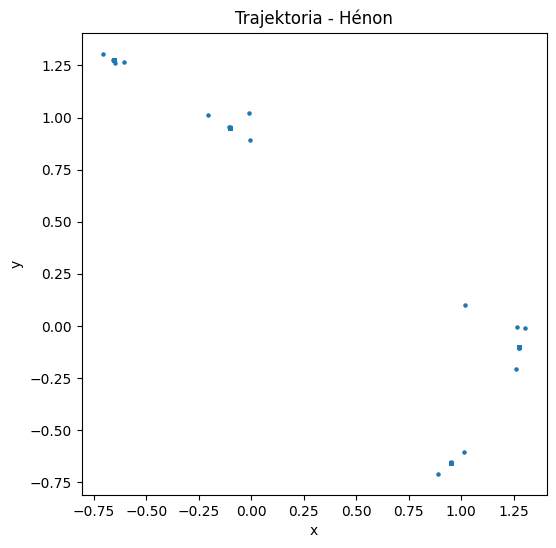

In [11]:
from zadanie3 import orbit

# parametry spełniające warunek orbity 2
b = -0.3
a = 1.0  # > 3/4*(1+b)^2 ≈ 0.975

x0, y0 = 0.1, 0.1
xs, ys = orbit(a, b, x0, y0, 500)

plt.figure(figsize=(6,6))
plt.scatter(xs, ys, s=5)
plt.title("Trajektoria - Hénon")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

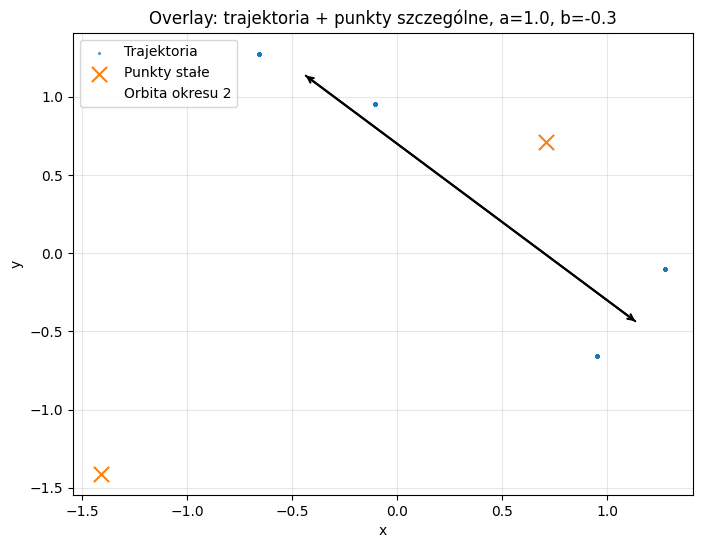

In [13]:
from zadanie4 import plot_overlay, plot_bifurcation
a_overlay = 1.0
b_overlay = -0.3
plot_overlay(a=a_overlay, b=b_overlay, x0=0.1, y0=0.1, n=4000, burn_in=100)

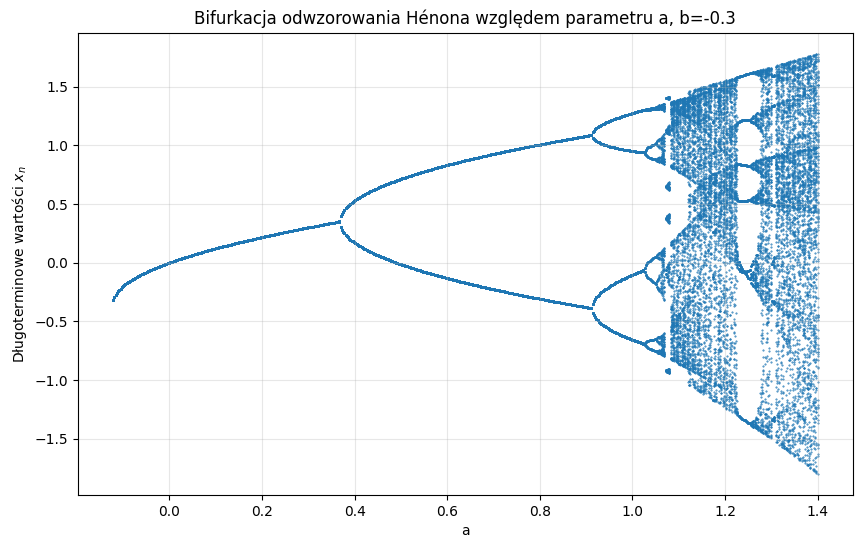

In [15]:
plot_bifurcation(
    b=-0.3,
    a_min=-1.0,
    a_max=1.4,
    a_steps=900,
    n_total=2000,
    n_keep=120,
    x0=0.1,
    y0=0.1
)

# Zadanie 5

Mamy klasyczne odwzorowanie Hénona

$$
h_{a,b}(x,y) = (a - by - x^2,; x).
$$

Chcemy pokazać, że jeśli punkty
$$
(x_1,y_1),\quad (x_2,y_2)
$$
tworzą orbitę okresu $2$, to

$$
x_1+y_1 = x_2+y_2 = x_1+x_2 = y_1+y_2 = 1+b.
$$

W szczególności wszystkie orbity okresu $2$ leżą na prostej

$$
x+y=1+b.
$$

---

## Założenie: punkty tworzą orbitę okresu 2

To znaczy, że

$$
h_{a,b}(x_1,y_1)=(x_2,y_2),
\qquad
h_{a,b}(x_2,y_2)=(x_1,y_1),
$$

oraz punkty są różne:
$$
(x_1,y_1)\neq (x_2,y_2).
$$

Z definicji odwzorowania Hénona dostajemy więc układ:

$$
\begin{cases}
x_2 = a - b y_1 - x_1^2, \
y_2 = x_1,
\end{cases}
$$

oraz

$$
\begin{cases}
x_1 = a - b y_2 - x_2^2, \
y_1 = x_2.
\end{cases}
$$

---

## Krok 1. Natychmiastowe zależności

Z drugich równań mamy od razu

$$
y_2=x_1,
\qquad
y_1=x_2.
$$

To już daje

$$
x_1+x_2 = x_1+y_1,
$$

bo $y_1=x_2$, oraz

$$
y_1+y_2 = x_2+x_1 = x_1+x_2.
$$

Podobnie

$$
x_2+y_2 = x_2+x_1 = x_1+x_2.
$$

A więc wszystkie cztery sumy są sobie równe:

$$
x_1+y_1 = x_2+y_2 = x_1+x_2 = y_1+y_2.
$$

Pozostaje pokazać, że wspólna wartość wynosi dokładnie $1+b$.

---

## Krok 2. Odejmujemy równania dla współrzędnych $x$

Mamy

$$
x_2 = a - b y_1 - x_1^2,
$$

$$
x_1 = a - b y_2 - x_2^2.
$$

Odejmujemy drugie równanie od pierwszego:

$$
x_2-x_1 = -b(y_1-y_2) - (x_1^2-x_2^2).
$$

Ponieważ
$$
y_1=x_2,\qquad y_2=x_1,
$$
to

$$
y_1-y_2 = x_2-x_1.
$$

Ponadto

$$
x_1^2-x_2^2 = (x_1-x_2)(x_1+x_2)=-(x_2-x_1)(x_1+x_2).
$$

Podstawiając, dostajemy

$$
x_2-x_1 = -b(x_2-x_1) + (x_2-x_1)(x_1+x_2).
$$

Wyłączamy czynnik $x_2-x_1$:

$$
(x_2-x_1)\bigl[1+b-(x_1+x_2)\bigr]=0.
$$

Ponieważ orbita ma okres dokładnie $2$, punkty są różne. Z równości
$$
y_1=x_2,\qquad y_2=x_1
$$
wynika wtedy w szczególności, że
$$
x_1\neq x_2.
$$

Zatem

$$
x_2-x_1\neq 0,
$$

więc musi zachodzić

$$
1+b-(x_1+x_2)=0.
$$

Czyli

$$
x_1+x_2=1+b.
$$

---

## Krok 3. Pozostałe sumy

Ponieważ już wiemy, że

$$
y_1=x_2,\qquad y_2=x_1,
$$

to natychmiast:

$$
x_1+y_1 = x_1+x_2 = 1+b,
$$

$$
x_2+y_2 = x_2+x_1 = 1+b,
$$

$$
y_1+y_2 = x_2+x_1 = 1+b.
$$

A więc rzeczywiście

$$
x_1+y_1 = x_2+y_2 = x_1+x_2 = y_1+y_2 = 1+b.
$$

To kończy dowód.

---

# Wniosek geometryczny

Każdy punkt orbity okresu $2$ spełnia równanie

$$
x+y=1+b.
$$

Zatem wszystkie orbity okresu $2$ odwzorowania Hénona leżą na prostej

$$
x+y=1+b.
$$

To dobrze zgadza się z wynikiem z poprzedniego zadania, gdzie dla orbit okresu $2$ otrzymywaliśmy warunek

$$
x+y=1+b.
$$

---

# Wersja skrócona do sprawozdania

Jeśli
$$
h_{a,b}(x_1,y_1)=(x_2,y_2), \qquad h_{a,b}(x_2,y_2)=(x_1,y_1),
$$
to z definicji odwzorowania Hénona
$$
h_{a,b}(x,y)=(a-by-x^2,;x)
$$
mamy
$$
y_2=x_1,\qquad y_1=x_2.
$$
Stąd od razu
$$
x_1+y_1=x_1+x_2,\qquad x_2+y_2=x_2+x_1,\qquad y_1+y_2=x_2+x_1,
$$
czyli wszystkie te sumy są równe $x_1+x_2$.

Dalej, z równań
$$
x_2=a-by_1-x_1^2,\qquad x_1=a-by_2-x_2^2
$$
po odjęciu stronami dostajemy
$$
x_2-x_1=-b(y_1-y_2)-(x_1^2-x_2^2).
$$
Ponieważ $y_1=x_2$ i $y_2=x_1$, mamy
$$
x_2-x_1=-b(x_2-x_1)+(x_2-x_1)(x_1+x_2),
$$
czyli
$$
(x_2-x_1)\bigl(1+b-(x_1+x_2)\bigr)=0.
$$
Dla orbity okresu $2$ zachodzi $x_1\neq x_2$, więc
$$
x_1+x_2=1+b.
$$
W konsekwencji
$$
x_1+y_1=x_2+y_2=x_1+x_2=y_1+y_2=1+b.
$$
A więc wszystkie punkty orbit okresu $2$ leżą na prostej
$$
x+y=1+b.
$$

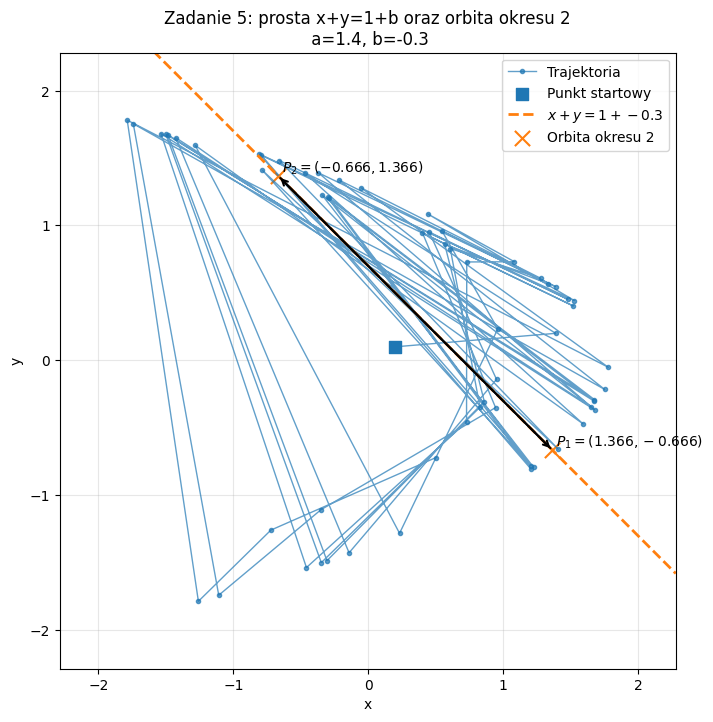

In [16]:
from zadanie5 import plot_task5
b = -0.3
a = 1.4   # bo 3/4*(1.3)^2 = 1.2675, więc warunek jest spełniony

x0, y0 = 0.2, 0.1
plot_task5(a=a, b=b, x0=x0, y0=y0, n=60, burn_in=0)

# Zadanie 6

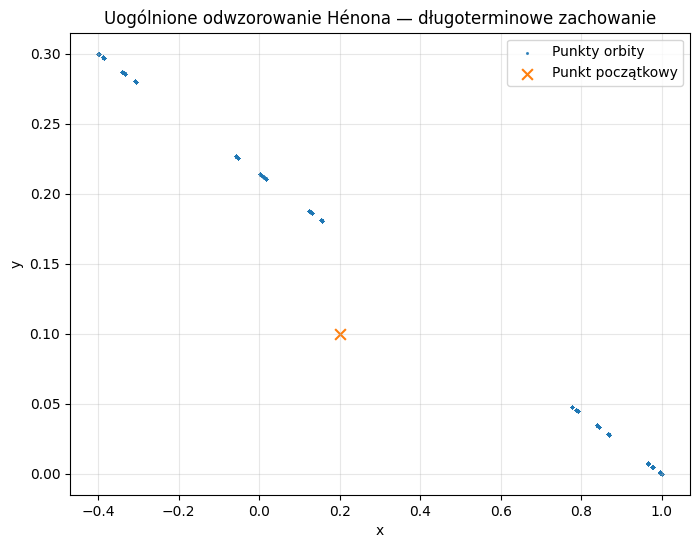

In [17]:
from zadanie6 import plot_generalized_henon
a = -1.4
b = 0.0
c = 0.0
d = 0.0
e = 1.0
r = 0.3
s = 0.0
t = 0.0
w = 0.0
u = 0.0
x0 = 0.2
y0 = 0.1
k = 5000
plot_generalized_henon(
    x0=x0,
    y0=y0,
    k=k,
    a=a, b=b, c=c, d=d, e=e,
    r=r, s=s, t=t, w=w, u=u,
    burn_in=100,
    point_size=1.5,
    connect_points=False
)

In [38]:
from zadani7 import plot_orbit

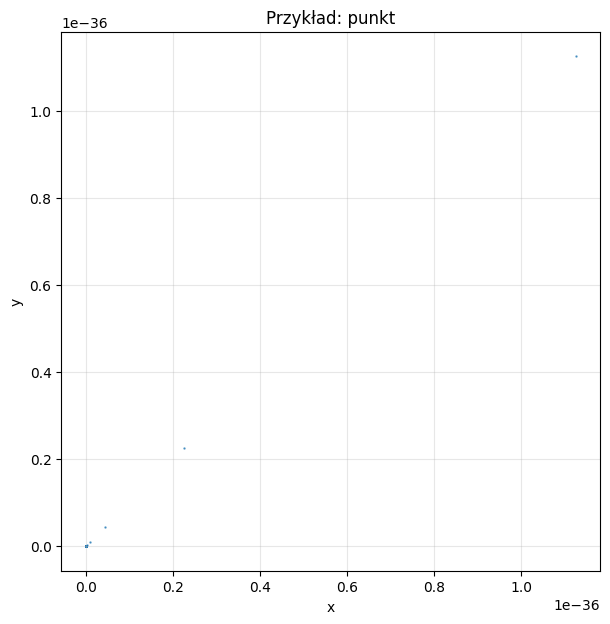

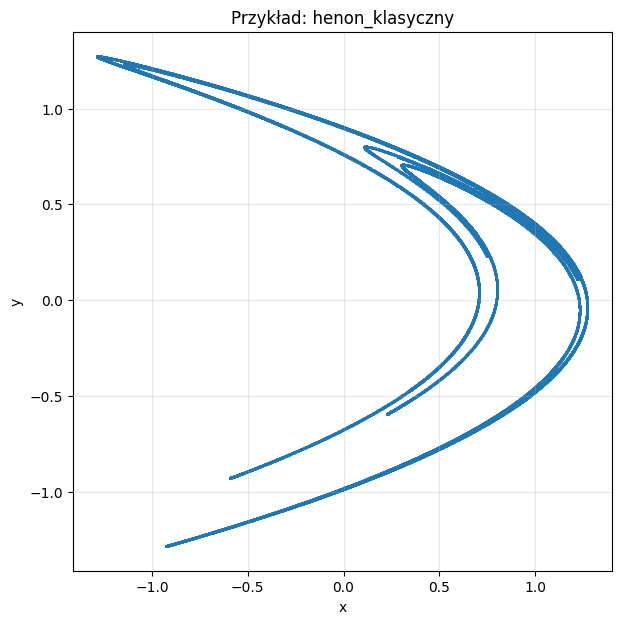

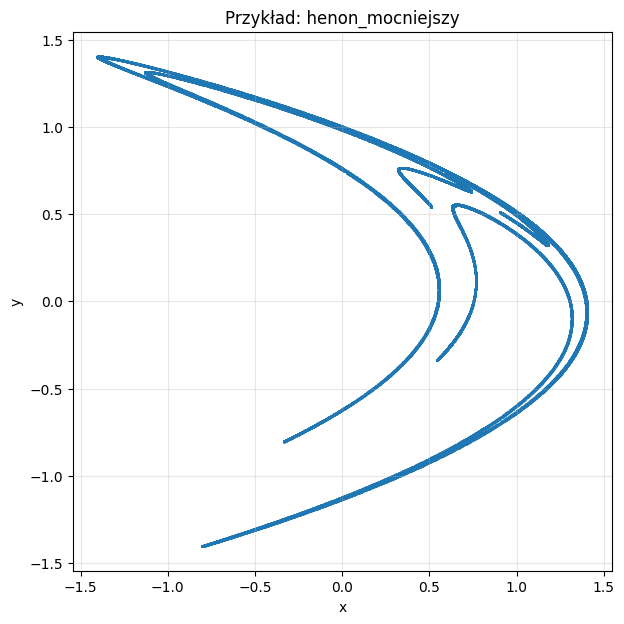

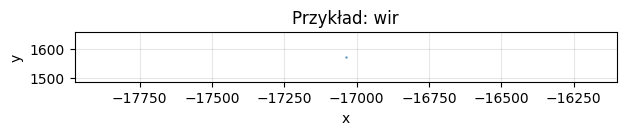

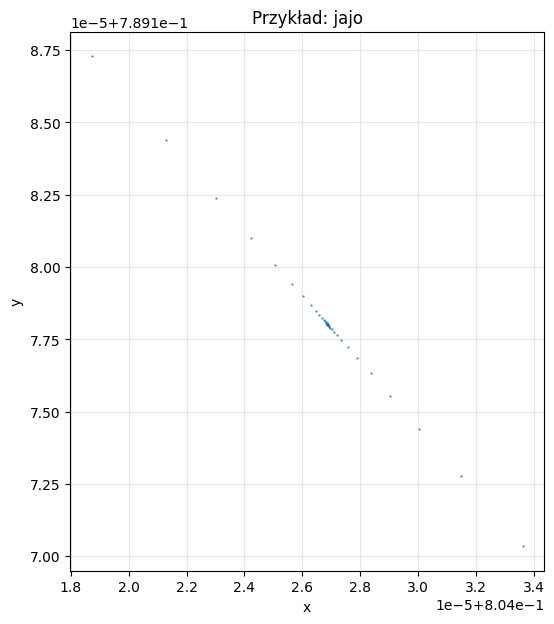

Trajektoria zbyt krótka po odrzuceniu burn-in.


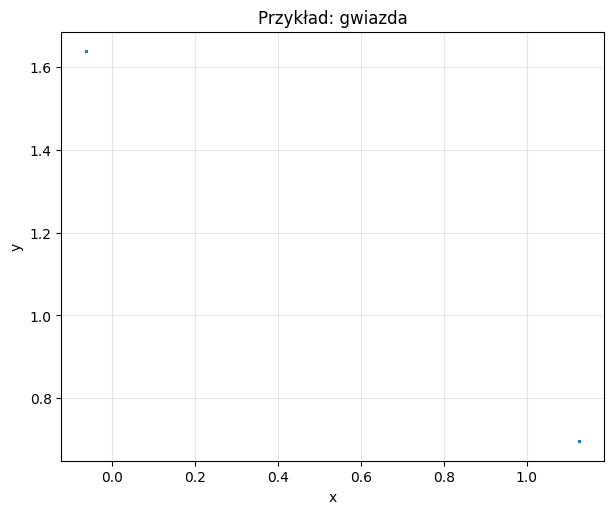

In [33]:
example_sets = {
    # 1. Punkt (OK - zostawiamy)
    "punkt": {
        "a": 0.0, "b": 0.0, "c": 0.2, "d": 0.0, "e": 0.0,
        "r": 0.0, "s": 0.0, "t": 0.0, "w": 0.2, "u": 0.0
    },

    # 2. Klasyczny Hénon (NAJWAŻNIEJSZE)
    "henon_klasyczny": {
        "a": -1.4, "b": 0.0, "c": 0.0, "d": 0.3, "e": 1.0,
        "r": 0.0,  "s": 0.0, "t": 1.0, "w": 0.0, "u": 0.0
    },

    # 3. Wzmocniony chaos (bardziej "gruby" atraktor)
    "henon_mocniejszy": {
        "a": -1.2, "b": 0.0, "c": 0.0, "d": 0.4, "e": 1.0,
        "r": 0.0,  "s": 0.0, "t": 1.0, "w": 0.0, "u": 0.0
    },

    # 4. Wir (rotacyjny efekt)
    "wir": {
        "a": -1.0, "b": 0.0, "c": 0.0, "d": 0.5, "e": 1.0,
        "r": 0.1,  "s": 0.0, "t": 1.0, "w": 0.2, "u": 0.0
    },

    # 5. Jajo (asymetria)
    "jajo": {
    "a": -0.6, "b": 0.02, "c": 0.4, "d": 0.2, "e": 0.7,
    "r": 0.05, "s": -0.01, "t": 0.9, "w": 0.05, "u": 0.0
},

    # 6. Wulkan (rozwarstwienie)
    "wulkan": {
        "a": -1.3, "b": 0.2, "c": 0.0, "d": 0.35, "e": 1.1,
        "r": 0.0,  "s": 0.0, "t": 1.0, "w": -0.2, "u": 0.0
    },

    # 7. Gwiazda / rozetka (niestabilne, ale ciekawe)
    "gwiazda": {
        "a": -1.0, "b": 0.3, "c": 0.3, "d": -0.4, "e": 1.0,
        "r": 0.2,  "s": 0.1, "t": 1.0, "w": 0.3, "u": 0.0
    }
}


for name in example_sets:
    params = example_sets[name]
    plot_orbit(
        params=params,
        x0=0.1,
        y0=0.1,
        n=80000,
        burn_in=50,
        point_size=0.5,
        title=f"Przykład: {name}"
)

In [34]:
example_sets = {
    "punkt": {
        "a": 0.0, "b": 0.0, "c": 0.2, "d": 0.0, "e": 0.0,
        "r": 0.0, "s": 0.0, "t": 0.0, "w": 0.2, "u": 0.0
    },

    "henon_klasyczny": {
        "a": -1.4, "b": 0.0, "c": 0.0, "d": 0.3, "e": 1.0,
        "r": 0.0, "s": 0.0, "t": 1.0, "w": 0.0, "u": 0.0
    },

    "henon_mocniejszy": {
        "a": -1.2, "b": 0.0, "c": 0.0, "d": 0.35, "e": 1.0,
        "r": 0.0, "s": 0.0, "t": 1.0, "w": 0.0, "u": 0.0
    },

    "owal": {
        "a": -0.75, "b": 0.01, "c": 0.25, "d": 0.20, "e": 0.85,
        "r": 0.03, "s": -0.01, "t": 0.95, "w": 0.03, "u": 0.0
    },

    "jajo": {
        "a": -0.60, "b": 0.02, "c": 0.35, "d": 0.18, "e": 0.75,
        "r": 0.04, "s": -0.01, "t": 0.92, "w": 0.04, "u": 0.0
    },

    "luk": {
        "a": -0.25, "b": 0.0, "c": 0.92, "d": 0.0, "e": 0.08,
        "r": 0.0, "s": 0.0, "t": 0.12, "w": 0.0, "u": 0.0
    },

    "splaszczony_chaos": {
        "a": -1.05, "b": 0.0, "c": 0.05, "d": 0.28, "e": 1.0,
        "r": 0.0, "s": 0.0, "t": 1.0, "w": -0.05, "u": 0.0
    }
}

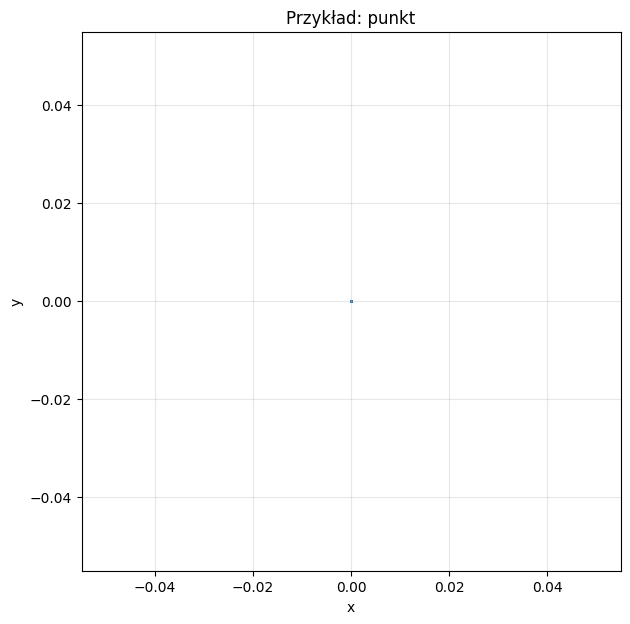

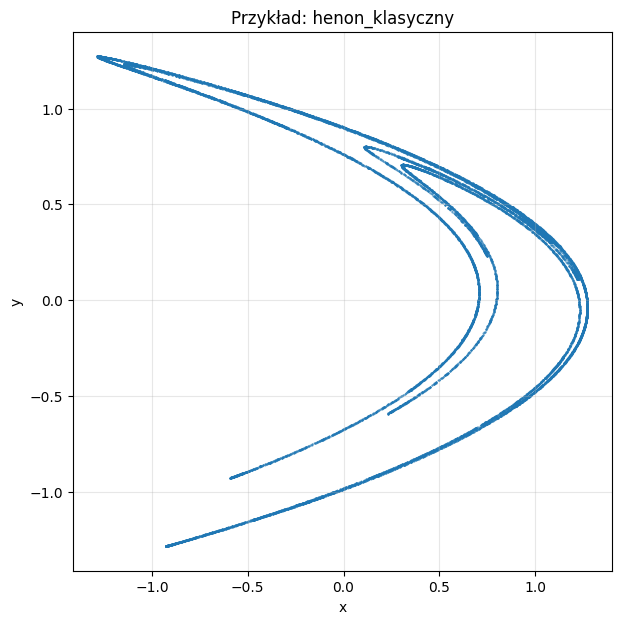

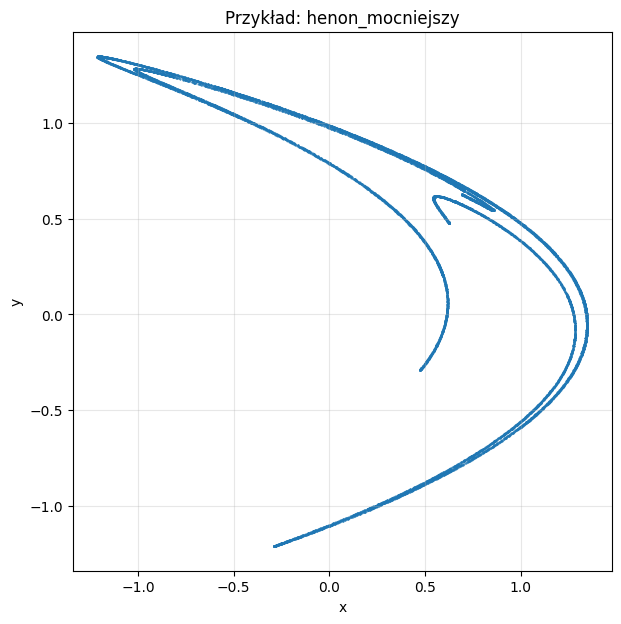

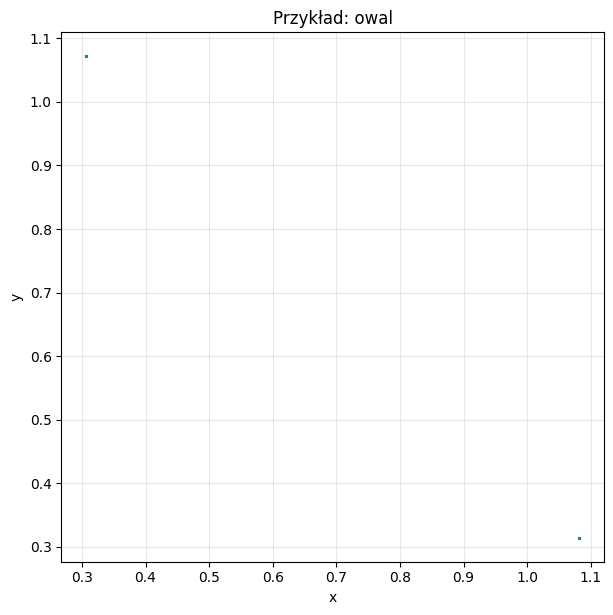

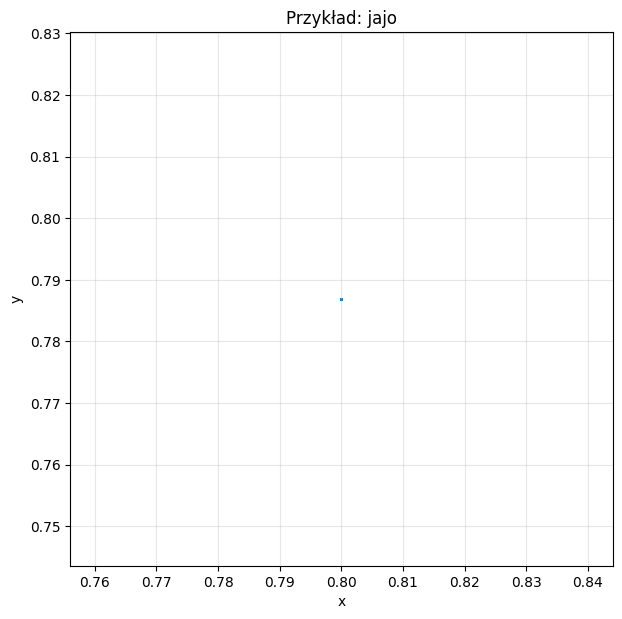

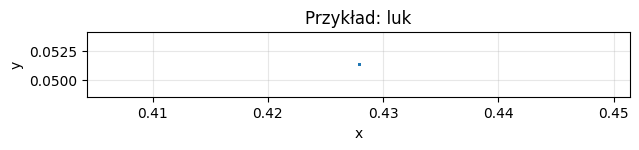

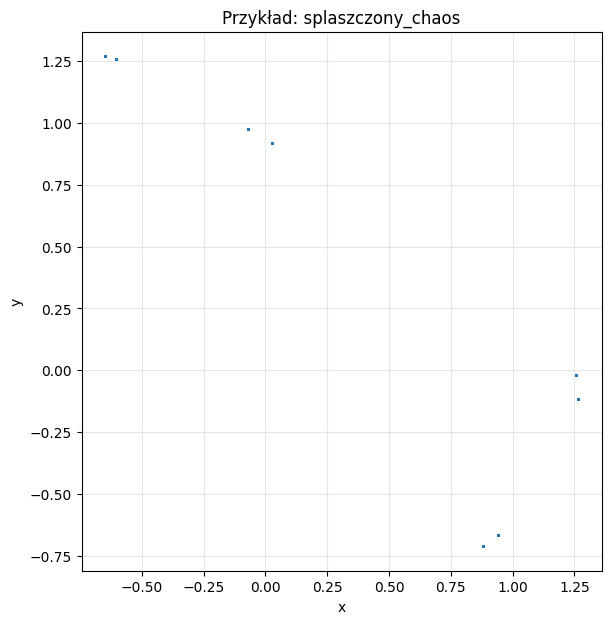

In [35]:
n=20000
burn_in=500
point_size=0.2

for name in example_sets:
    params = example_sets[name]
    plot_orbit(
        params=params,
        x0=0.1,
        y0=0.1,
        n=n,
        burn_in=burn_in,
        point_size=point_size,
        title=f"Przykład: {name}"
)

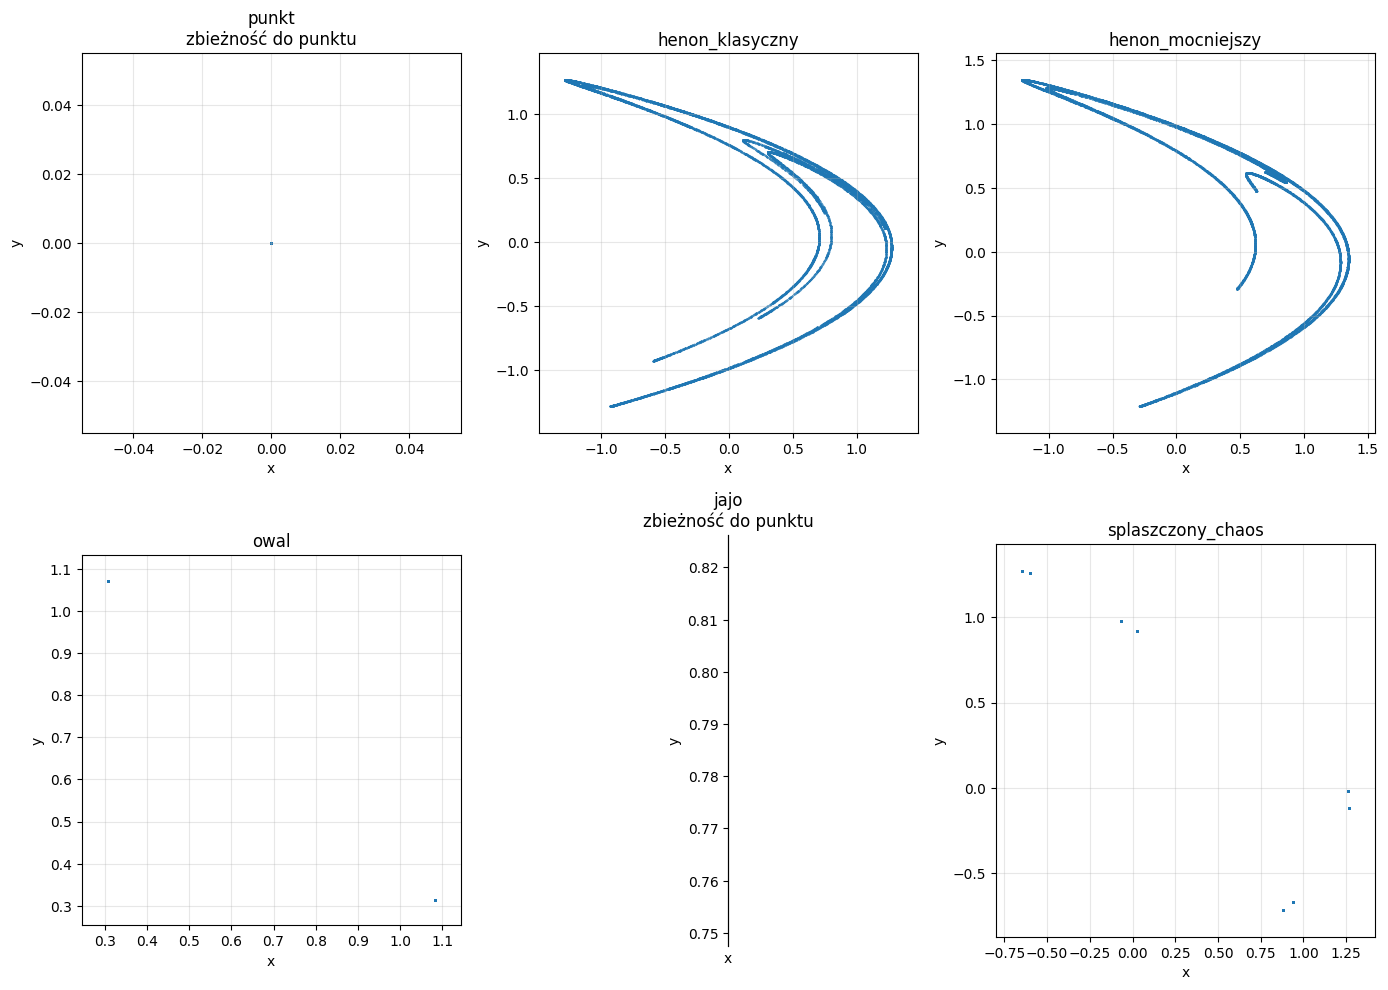

In [43]:
import numpy as np
import matplotlib.pyplot as plt


def generalized_henon_map(
    x: float,
    y: float,
    a: float,
    b: float,
    c: float,
    d: float,
    e: float,
    r: float,
    s: float,
    t: float,
    w: float,
    u: float
) -> tuple[float, float]:
    x_new = a * x**2 + b * y**2 + c * x + d * y + e
    y_new = r * x**2 + s * y**2 + t * x + w * y + u
    return x_new, y_new


def compute_orbit(
    x0: float,
    y0: float,
    n: int,
    a: float,
    b: float,
    c: float,
    d: float,
    e: float,
    r: float,
    s: float,
    t: float,
    w: float,
    u: float,
    divergence_limit: float = 1e6
) -> tuple[np.ndarray, np.ndarray, bool]:
    xs = np.empty(n + 1, dtype=float)
    ys = np.empty(n + 1, dtype=float)

    xs[0] = x0
    ys[0] = y0

    x, y = x0, y0
    diverged = False

    for i in range(1, n + 1):
        x, y = generalized_henon_map(x, y, a, b, c, d, e, r, s, t, w, u)
        xs[i] = x
        ys[i] = y

        if not np.isfinite(x) or not np.isfinite(y) or abs(x) > divergence_limit or abs(y) > divergence_limit:
            diverged = True
            return xs[:i+1], ys[:i+1], diverged

    return xs, ys, diverged


def plot_orbit(
    params: dict,
    x0: float = 0.1,
    y0: float = 0.1,
    n: int = 20000,
    burn_in: int | None = None,
    point_size: float = 0.15,
    title: str | None = None,
    divergence_limit: float = 1e6,
    min_points_to_plot: int = 300
) -> None:
    xs, ys, diverged = compute_orbit(
        x0=x0,
        y0=y0,
        n=n,
        a=params["a"],
        b=params["b"],
        c=params["c"],
        d=params["d"],
        e=params["e"],
        r=params["r"],
        s=params["s"],
        t=params["t"],
        w=params["w"],
        u=params["u"],
        divergence_limit=divergence_limit
    )

    total_points = len(xs)

    if burn_in is None:
        burn_in = min(1000, max(50, total_points // 10))
    else:
        burn_in = min(burn_in, max(0, total_points // 5))

    if total_points <= burn_in + 5:
        print(f"{title}: trajektoria zbyt krótka (punktów: {total_points}, burn_in: {burn_in})")
        return

    xs_plot = xs[burn_in:]
    ys_plot = ys[burn_in:]

    # dodatkowe obcięcie skrajnych wartości, żeby pojedyncze odloty nie psuły skali
    finite_mask = np.isfinite(xs_plot) & np.isfinite(ys_plot)
    xs_plot = xs_plot[finite_mask]
    ys_plot = ys_plot[finite_mask]

    if len(xs_plot) < 5:
        print(f"{title}: po filtracji zostało za mało punktów do sensownego rysunku.")
        return

    # sprawdzenie, czy to prawie punkt / prawie cykl o bardzo małym rozrzucie
    spread_x = np.max(xs_plot) - np.min(xs_plot)
    spread_y = np.max(ys_plot) - np.min(ys_plot)

    plt.figure(figsize=(7, 7))
    plt.scatter(xs_plot, ys_plot, s=point_size, alpha=0.7)

    if title is None:
        title = "Uogólniony układ Hénona"

    if diverged:
        title += " [trajektoria przerwana]"

    if spread_x < 1e-4 and spread_y < 1e-4:
        title += " [zbieżność do punktu / krótkiego cyklu]"

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(alpha=0.3)

    # sensowne ustawienie osi
    if spread_x > 0 and spread_y > 0:
        margin_x = 0.08 * spread_x
        margin_y = 0.08 * spread_y
        plt.xlim(np.min(xs_plot) - margin_x, np.max(xs_plot) + margin_x)
        plt.ylim(np.min(ys_plot) - margin_y, np.max(ys_plot) + margin_y)

    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()
    
def plot_examples_grid(example_sets, starts, n=20000, point_size=0.15):
    fig, axes = plt.subplots(2, 3, figsize=(14, 10))
    axes = axes.ravel()

    for ax, (name, params) in zip(axes, example_sets.items()):
        x0, y0 = starts[name]

        xs, ys, diverged = compute_orbit(
            x0=x0,
            y0=y0,
            n=n,
            a=params["a"],
            b=params["b"],
            c=params["c"],
            d=params["d"],
            e=params["e"],
            r=params["r"],
            s=params["s"],
            t=params["t"],
            w=params["w"],
            u=params["u"],
            divergence_limit=1e6
        )

        total_points = len(xs)
        burn_in = min(1000, max(50, total_points // 10))

        if total_points <= burn_in + 5:
            ax.set_title(f"{name}\nza krótka trajektoria")
            ax.grid(alpha=0.3)
            continue

        xs_plot = xs[burn_in:]
        ys_plot = ys[burn_in:]

        finite_mask = np.isfinite(xs_plot) & np.isfinite(ys_plot)
        xs_plot = xs_plot[finite_mask]
        ys_plot = ys_plot[finite_mask]

        if len(xs_plot) < 5:
            ax.set_title(f"{name}\nza mało punktów")
            ax.grid(alpha=0.3)
            continue

        ax.scatter(xs_plot, ys_plot, s=point_size, alpha=0.7)

        spread_x = np.max(xs_plot) - np.min(xs_plot)
        spread_y = np.max(ys_plot) - np.min(ys_plot)

        subtitle = name
        if diverged:
            subtitle += "\nprzerwana trajektoria"
        elif spread_x < 1e-4 and spread_y < 1e-4:
            subtitle += "\nzbieżność do punktu"

        ax.set_title(subtitle)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.grid(alpha=0.3)
        ax.set_aspect("equal", adjustable="box")

        if spread_x > 0 and spread_y > 0:
            margin_x = 0.08 * spread_x
            margin_y = 0.08 * spread_y
            ax.set_xlim(np.min(xs_plot) - margin_x, np.max(xs_plot) + margin_x)
            ax.set_ylim(np.min(ys_plot) - margin_y, np.max(ys_plot) + margin_y)

    plt.tight_layout()
    plt.show()


plot_examples_grid(example_sets, starts, n=20000, point_size=0.12)